To run the notebook on a virtual environment, use the uv package manager, or run:

```
python -m venv qiskit1_env
source qiskit1_env/bin/activate
pip install .
python -m ipykernel install --user --name=qiskit1_env
```
And then choose qiskit1_env as kernel within jupyter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, generate_preset_pass_manager
from qiskit.circuit import Qubit
from qiskit.circuit.library import RYGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import OptimizeAnnotated
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2

from qiskit_algorithms import EstimationProblem, AmplitudeEstimation

from lib.gates import TranspositionGate, delay_gate, apply_on_buffer, process_sample, big_endian_bit_str
from lib.fir_util import power_complementary_fir, direct_pair_to_lattice_real, lattice_freq_response

plt.style.use("plots.mplstyle")

1.0009065686628422 0.007870788188631269


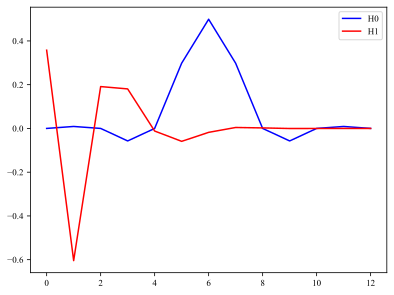

In [2]:
# Design a filter H0 and its power complement H1

H0 = scipy.signal.firwin(13, 0.5)
# Try to ensure filter is bounded <= 1
gain_adjust = np.max(np.abs(scipy.signal.freqz(H0)[1]))
print(gain_adjust, 20*np.log10(gain_adjust))
H0 /= gain_adjust
H1 = power_complementary_fir(H0)

plt.plot(H0, 'b', label='H0')
plt.plot(H1, 'r', label='H1')
plt.legend()
plt.show()

[ 7.66415950e-06 -5.03227544e-02 -8.49485920e-02  2.01980502e-01
  4.03725024e-01 -9.16198690e-01 -2.16498917e+00 -9.16198650e-01
  4.03732727e-01  2.01993156e-01 -8.49392262e-02 -5.03220041e-02
  3.14159265e+00]


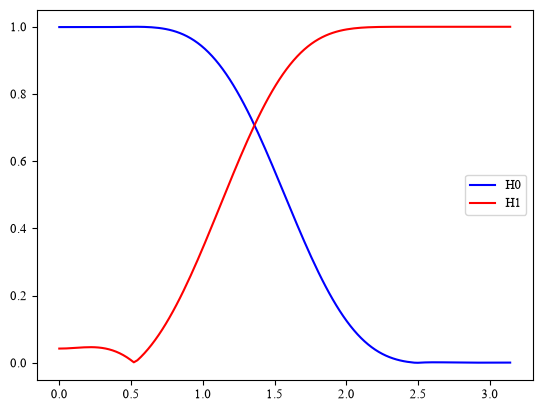

H1 has a bump in low frequency. This is caused by small ripple in the H0 passband, which gets amplified to satisfy |H0|^2 + |H1|^2 = 1.


In [14]:
# Convert direct form to lattice coefficients

theta = direct_pair_to_lattice_real(H0, H1)
print(theta)

# Check frequency response
freq = np.linspace(0, np.pi, 128)
H0f, H1f = lattice_freq_response(theta, freq)

plt.plot(freq, np.abs(H0f), 'b', label='H0')
plt.plot(freq, np.abs(H1f), 'r', label='H1')
plt.legend()
plt.show()
print('H1 has a bump in low frequency. This is caused by small ripple in the H0 passband, which gets amplified to satisfy |H0|^2 + |H1|^2 = 1.')

![quantum FIR circuit](./figures/quantumFIR.png)

In [4]:
def fir_circ_real(circ: QuantumCircuit, b_reg, q_reg, theta, proj_delay: int):
    """
    Construct FIR circuit.

    Buffer k=0 used as work buffer. k=1,...,order used for unit delays,
    and k=order+1 used for projection.
    """

    order = len(theta) - 1

    for i in range(order+1):
        if i > 0:
            delay_gate(circ, b_reg, q_reg, 0, '1', delay=1, buffer=i)
        apply_on_buffer(circ, b_reg, q_reg, RYGate(theta[i]), 0)
    
    delay_gate(circ, b_reg, q_reg, 0, '1', delay=proj_delay, buffer=order+1)

simulator = AerSimulator(method="statevector")
pass_manager = generate_preset_pass_manager(0, simulator)

def aer_get_statevector(circ: QuantumCircuit):
    global simulator, pass_manager
    circ_transp = pass_manager.run(circ)
    circ_transp.save_statevector()

    result = simulator.run(circ_transp, shots=0).result()
    return result.get_statevector()



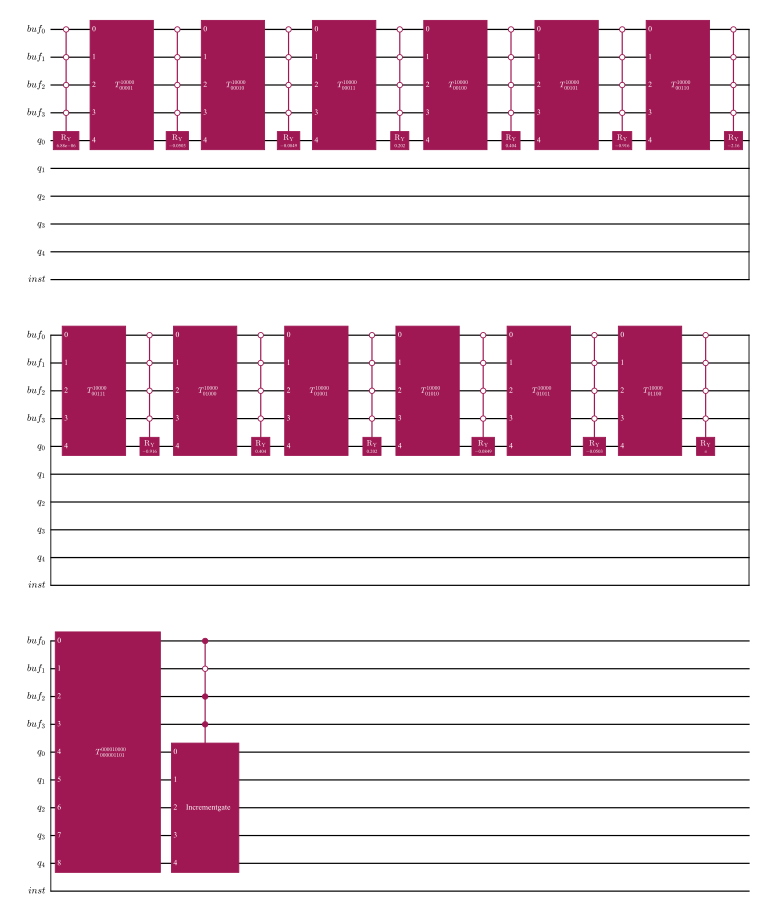

In [5]:
# Buffer register (add more qubits to support higher-order filter)
b_reg = QuantumRegister(4, "buf")
# Data register (more qubits for longer signal)
q_reg = QuantumRegister(5, "q")
# Instance register (two separate signal & filter instances)
inst_reg = QuantumRegister(1, "inst")

fir_circ = QuantumCircuit(b_reg, q_reg, inst_reg)

fir_circ_real(fir_circ, b_reg, q_reg, theta, 2**len(q_reg))

fir_circ.draw("mpl", scale=0.6)

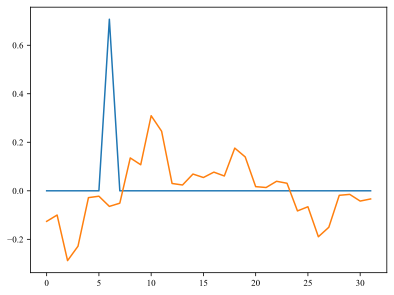

In [6]:
# Prepare a signal in buffer -1 for both instances

prepare = QuantumCircuit(b_reg, q_reg, inst_reg)

# Split energy between instances
prepare.h(inst_reg)

# Select buffer 0b11..1
prepare.x(b_reg)

# Superposition of two signals:
# Instance 0: Impulse at sample 6 = 0b110
prepare.cx(inst_reg, [q_reg[2], q_reg[1]], ctrl_state='0')
# # Step function
# prepare.ch(inst_reg, q_reg[:-1], ctrl_state='0')

# Instance 1: Random Ry gates for "fractal" signal
np.random.seed(72)
for q in q_reg:
    prepare.cry(np.random.uniform(-2*np.pi, 2*np.pi), inst_reg, q, ctrl_state='1')


prepare.draw("mpl", scale=0.6)

st = aer_get_statevector(prepare)

stride = 2**len(b_reg)
data = st.data[stride-1::stride]
signal_x = np.real(np.reshape(data, (2**len(inst_reg), -1)))

plt.plot(signal_x[0])
plt.plot(signal_x[1])
plt.show()


In [7]:
# Filter the signal(s)

full_circ = QuantumCircuit(b_reg, q_reg, inst_reg)

full_circ.compose(prepare, inplace=True)

for i in range(2**len(q_reg)):
    process_sample(
        full_circ, b_reg, q_reg,
        fir_circ,
        sample_buffer=2**len(b_reg)-1, sample_pos=i,
        proc_buffer=0
    )

# Too large to draw
# full_circ.draw("mpl", scale=0.6)

In [8]:
# Read output signals from the state vector
st = aer_get_statevector(full_circ)

stride = 2**len(b_reg)
data = st.data[stride-1::stride]
signal_y = np.real(np.reshape(data, (2**len(inst_reg), -1)))

In [9]:
# Read output signals with Hadamard test

# The circuit is re-run for each sample.
# This is quite slow (mostly due to Qiskit unnecessarily blowing up the circuit)

def hadamard_test_circ_real(U_ctrl: QuantumCircuit, out_basis: str):
    """
    Design Hadamard test circuit to estimate Re <out_basis|U|0>

    ctrl_unitary should be a 1-controlled variant of the desired unitary, first qubit is control
    """
    ancilla = U_ctrl.qubits[0]
    ht = QuantumCircuit(U_ctrl.qubits)
    ht.h(U_ctrl.qubits[0])
    ht.compose(U_ctrl, inplace=True)
    for i, bit in enumerate(reversed(out_basis)):
        if bit == '1':
            ht.cx(ancilla, U_ctrl.qubits[i + 1])
    ht.h(U_ctrl.qubits[0])
    return ht

ancilla = Qubit()
ctrl_circ = QuantumCircuit([ancilla, *full_circ.qubits])
ctrl_circ.append(full_circ.control(1, annotated=True), ctrl_circ.qubits)
full_circ_transp = pass_manager.run(ctrl_circ)

signal_y_meas = []

for inst in ['0', '1']:
    print("Instance", inst)
    data = []
    for i in range(2**len(q_reg)):
        basis = inst + big_endian_bit_str(len(q_reg), i) + '1' * len(b_reg)
        ht_circ = hadamard_test_circ_real(full_circ_transp, basis)
        ht_circ.add_register(ClassicalRegister(1))
        ht_circ.measure(ancilla, 0)

        shots = 1024
        result = simulator.run(ht_circ, shots=shots).result()
        estimate = 2 * result.get_counts()['0'] / shots - 1
        data.append(estimate)
    signal_y_meas.append(data)


Instance 0
Instance 1


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


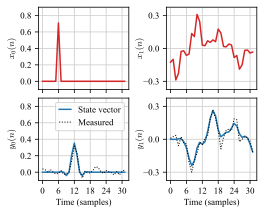

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(3.5, 2.8),
    layout="constrained", sharex=True)

fig.get_layout_engine().set(w_pad=1/72, h_pad=1/72, wspace=0.05, hspace=0.05)

i0_ylim = (-0.1, 0.9)
i1_ylim = (-0.375, 0.375)
i0_yticks = np.linspace(0.0, 0.8, 5)
i1_yticks = np.linspace(-0.3, 0.3, 3)
xticks = [0, 6, 12, 18, 24, 30]

for ax in axs.flat:
    ax.set_xticks(xticks)
    ax.grid(color='0.8')

plt.sca(axs[0, 0])
plt.plot(signal_x[0], color="tab:red")
plt.ylim(i0_ylim)
plt.yticks(i0_yticks)
plt.ylabel("$x_0(n)$")
# plt.legend()
# plt.title("(a)", y=-0.24)

plt.sca(axs[0, 1])
plt.plot(signal_x[1], color="tab:red")
plt.ylim(i1_ylim)
plt.yticks(i1_yticks)
plt.ylabel("$x_1(n)$", labelpad=-1)
# plt.title("(b)", y=-0.24)

plt.sca(axs[1, 0])
plt.plot(signal_y[0], label="State vector")
plt.plot(signal_y_meas[0], linestyle='dotted', color='black', linewidth=1, label="Measured")
plt.ylim(i0_ylim)
plt.yticks(i0_yticks)
plt.xlabel("Time (samples)", labelpad=3)
plt.ylabel("$y_0(n)$")
plt.legend(handlelength=1.3)
# plt.title("(c)", y=-0.54)

plt.sca(axs[1, 1])
plt.plot(signal_y[1])
plt.plot(signal_y_meas[1], linestyle='dotted', color='black', linewidth=1)
plt.ylim(i1_ylim)
plt.yticks(i1_yticks)
plt.xlabel("Time (samples)", labelpad=3)
plt.ylabel("$y_1(n)$", labelpad=-1)
# plt.title("(d)", y=-0.54)

plt.savefig("figures/fig3_v2.pdf")
plt.show()